In [49]:
from MiniImageNet import MiniImageNet
# Set dataset path
dataset_path = "/Users/jadentjeng/Downloads/archive-4"

# Create train, validation, and test datasets
train_dataset = MiniImageNet(root=dataset_path, split="train", transform=transform)
val_dataset = MiniImageNet(root=dataset_path, split="val", transform=transform)
test_dataset = MiniImageNet(root=dataset_path, split="test", transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(train_dataset)

                    filename      label
0      n0153282900000006.jpg  n01532829
1      n0153282900000007.jpg  n01532829
2      n0153282900000010.jpg  n01532829
3      n0153282900000014.jpg  n01532829
4      n0153282900000015.jpg  n01532829
...                      ...        ...
38394  n1313361300001288.jpg  n13133613
38395  n1313361300001290.jpg  n13133613
38396  n1313361300001296.jpg  n13133613
38397  n1313361300001297.jpg  n13133613
38398  n1313361300001299.jpg  n13133613

[38399 rows x 2 columns]
                   filename      label
0     n0185567200000003.jpg  n01855672
1     n0185567200000004.jpg  n01855672
2     n0185567200000010.jpg  n01855672
3     n0185567200000013.jpg  n01855672
4     n0185567200000016.jpg  n01855672
...                     ...        ...
9595  n0925647900001283.jpg  n09256479
9596  n0925647900001284.jpg  n09256479
9597  n0925647900001285.jpg  n09256479
9598  n0925647900001286.jpg  n09256479
9599  n0925647900001291.jpg  n09256479

[9600 rows x 2 columns]
 

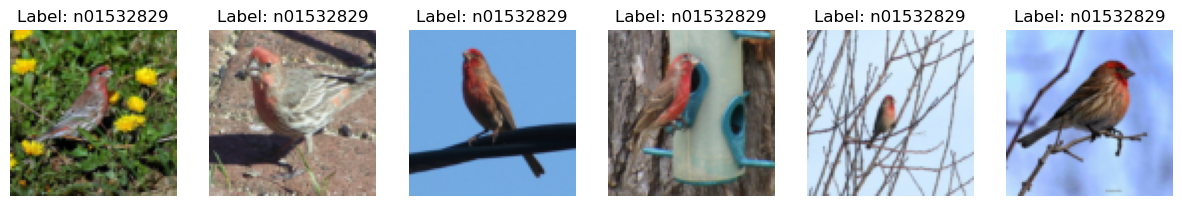

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

# Function to show images
def show_images(dataset, num_samples=6):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    
    for i in range(num_samples):
        image, label = dataset[i]  # Get image and label
        image = image.permute(1, 2, 0) # Convert from Tensor to NumPy
        
        # Undo normalization to view original image
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        image = image * std + mean  # De-normalize
        image = torch.clip(image, 0, 1)  # Ensure valid pixel range
        
        axes[i].imshow(image)
        axes[i].set_title(f"Label: {label}")
        axes[i].axis("off")
    
    plt.show()

# Show some train dataset samples
show_images(train_dataset)


In [53]:
import torch.nn as nn


def conv_block(in_channels, out_channels):
    '''
    returns a block conv-bn-relu-pool
    '''
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )


class ProtoNet(nn.Module):
    '''
    Model as described in the reference paper,
    source: https://github.com/jakesnell/prototypical-networks/blob/f0c48808e496989d01db59f86d4449d7aee9ab0c/protonets/models/few_shot.py#L62-L84
    '''
    def __init__(self, x_dim=1, hid_dim=64, z_dim=64):
        super(ProtoNet, self).__init__()
        self.encoder = nn.Sequential(
            conv_block(x_dim, hid_dim),
            conv_block(hid_dim, hid_dim),
            conv_block(hid_dim, hid_dim),
            conv_block(hid_dim, z_dim),
        )

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)


Using device: cpu
Epoch 1/50


Validating: 100%|███████████████████████████████| 50/50 [00:25<00:00,  1.98it/s]


Train Loss: 21.4067, Train Acc: 0.4448
Val Loss: 4.5678, Val Acc: 0.4035
Model saved with validation accuracy: 0.4035
Epoch 2/50


Validating: 100%|███████████████████████████████| 50/50 [00:24<00:00,  2.02it/s]


Train Loss: 2.3641, Train Acc: 0.4285
Val Loss: 1.7145, Val Acc: 0.3877
Epoch 3/50


...

Train Loss: 0.8616, Train Acc: 0.6640
Val Loss: 1.1016, Val Acc: 0.5619
Epoch 50/50


Validating: 100%|███████████████████████████████| 50/50 [00:29<00:00,  1.70it/s]


Train Loss: 0.8827, Train Acc: 0.6583
Val Loss: 1.0703, Val Acc: 0.5733
Loaded model from epoch 41 with validation accuracy 0.5776


Testing: 100%|████████████████████████████████| 100/100 [00:54<00:00,  1.82it/s]


Test Accuracy: 0.5816


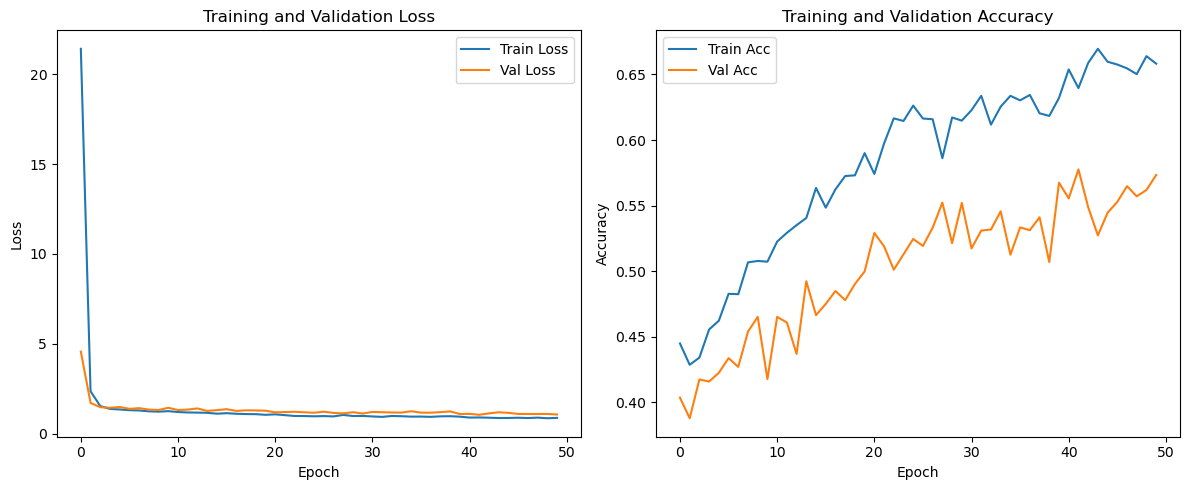

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from tqdm import tqdm
import os

# Set random seeds for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the ProtoNet model
model = ProtoNet(x_dim=3, hid_dim=64, z_dim=64)  # 3 channels for RGB images
model = model.to(device)

# Define the episodic training parameters
n_way = 5  # Number of classes per episode
n_support = 5  # Number of support samples per class (K-shot)
n_query = 15  # Number of query samples per class
n_episodes = 100  # Number of episodes per epoch

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Define prototypical loss function
def prototypical_loss(prototypes, query_samples, query_labels):
    """
    Calculate the prototypical loss as the negative log probability of the correct class.
    
    Args:
        prototypes: Tensor of shape (n_way, embedding_dim) - the prototype of each class
        query_samples: Tensor of shape (n_queries, embedding_dim) - the embedded query samples
        query_labels: Tensor of shape (n_queries) - the labels of the query samples
        
    Returns:
        Loss value and accuracy
    """
    # Calculate distances between query samples and prototypes
    dists = torch.cdist(query_samples, prototypes)**2  # Squared Euclidean distance
    
    # Calculate negative log probability of the correct class
    log_p_y = torch.nn.functional.log_softmax(-dists, dim=1)
    
    # Get the target indices
    target_inds = query_labels
    
    # Calculate the loss
    loss = -log_p_y.gather(1, target_inds.unsqueeze(1)).mean()
    
    # Calculate accuracy
    _, y_hat = log_p_y.max(1)
    acc = torch.eq(y_hat, target_inds).float().mean()
    
    return loss, acc

# Create a class mapping for episode construction
def create_class_mapping(dataset):
    """Create a mapping from class labels to indices of samples with that label."""
    class_map = {}
    for idx, (_, label) in enumerate(dataset):
        if label not in class_map:
            class_map[label] = []
        class_map[label].append(idx)
    return class_map

# Function to create episodic data loader
def create_episode(dataset, class_map, n_way, n_support, n_query):
    """Create an episode for few-shot learning."""
    # Randomly select n_way classes
    classes = random.sample(list(class_map.keys()), n_way)
    
    support_samples = []
    support_labels = []
    query_samples = []
    query_labels = []
    
    for i, cls in enumerate(classes):
        # Get indices of samples for this class
        cls_indices = class_map[cls]
        
        # Randomly select n_support + n_query samples
        selected_indices = random.sample(cls_indices, n_support + n_query)
        
        # Split into support and query sets
        support_indices = selected_indices[:n_support]
        query_indices = selected_indices[n_support:]
        
        # Add samples to support and query sets
        for idx in support_indices:
            img, _ = dataset[idx]
            support_samples.append(img)
            support_labels.append(i)  # Use index as the label
        
        for idx in query_indices:
            img, _ = dataset[idx]
            query_samples.append(img)
            query_labels.append(i)  # Use index as the label
    
    # Convert to tensors
    support_samples = torch.stack(support_samples)
    support_labels = torch.tensor(support_labels)
    query_samples = torch.stack(query_samples)
    query_labels = torch.tensor(query_labels)
    
    return support_samples, support_labels, query_samples, query_labels

# Create class mappings
train_class_map = create_class_mapping(train_dataset)
val_class_map = create_class_mapping(val_dataset)

# Training function
def train_epoch(model, train_dataset, train_class_map, n_episodes):
    model.train()
    total_loss = 0
    total_acc = 0
    
    for episode in tqdm(range(n_episodes), desc="Training"):
        # Create episode
        support_samples, support_labels, query_samples, query_labels = create_episode(
            train_dataset, train_class_map, n_way, n_support, n_query
        )
        
        # Move to device
        support_samples = support_samples.to(device)
        support_labels = support_labels.to(device)
        query_samples = query_samples.to(device)
        query_labels = query_labels.to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Compute embeddings
        support_embeddings = model(support_samples)
        query_embeddings = model(query_samples)
        
        # Compute prototypes
        prototypes = torch.zeros(n_way, support_embeddings.shape[1]).to(device)
        for i in range(n_way):
            mask = support_labels == i
            prototypes[i] = support_embeddings[mask].mean(0)
        
        # Compute loss and accuracy
        loss, acc = prototypical_loss(prototypes, query_embeddings, query_labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_acc += acc.item()
    
    return total_loss / n_episodes, total_acc / n_episodes

# Validation function
def validate(model, val_dataset, val_class_map, n_episodes):
    model.eval()
    total_loss = 0
    total_acc = 0
    
    with torch.no_grad():
        for episode in tqdm(range(n_episodes), desc="Validating"):
            # Create episode
            support_samples, support_labels, query_samples, query_labels = create_episode(
                val_dataset, val_class_map, n_way, n_support, n_query
            )
            
            # Move to device
            support_samples = support_samples.to(device)
            support_labels = support_labels.to(device)
            query_samples = query_samples.to(device)
            query_labels = query_labels.to(device)
            
            # Compute embeddings
            support_embeddings = model(support_samples)
            query_embeddings = model(query_samples)
            
            # Compute prototypes
            prototypes = torch.zeros(n_way, support_embeddings.shape[1]).to(device)
            for i in range(n_way):
                mask = support_labels == i
                prototypes[i] = support_embeddings[mask].mean(0)
            
            # Compute loss and accuracy
            loss, acc = prototypical_loss(prototypes, query_embeddings, query_labels)
            
            total_loss += loss.item()
            total_acc += acc.item()
    
    return total_loss / n_episodes, total_acc / n_episodes

# Main training loop
def train_model(model, train_dataset, val_dataset, n_epochs, n_episodes):
    best_val_acc = 0
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    for epoch in range(n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs}")
        
        # Train
        train_loss, train_acc = train_epoch(model, train_dataset, train_class_map, n_episodes)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validate
        val_loss, val_acc = validate(model, val_dataset, val_class_map, n_episodes//2)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Update learning rate
        lr_scheduler.step()
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, 'best_protonet_model.pth')
            print(f"Model saved with validation accuracy: {val_acc:.4f}")
    
    return train_losses, train_accs, val_losses, val_accs

# Test function
def test_model(model, test_dataset, n_episodes):
    # Load best model
    checkpoint = torch.load('best_protonet_model.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch {checkpoint['epoch']} with validation accuracy {checkpoint['val_acc']:.4f}")
    
    # Create class mapping for test set
    test_class_map = create_class_mapping(test_dataset)
    
    # Test
    model.eval()
    total_acc = 0
    
    with torch.no_grad():
        for episode in tqdm(range(n_episodes), desc="Testing"):
            # Create episode
            support_samples, support_labels, query_samples, query_labels = create_episode(
                test_dataset, test_class_map, n_way, n_support, n_query
            )
            
            # Move to device
            support_samples = support_samples.to(device)
            support_labels = support_labels.to(device)
            query_samples = query_samples.to(device)
            query_labels = query_labels.to(device)
            
            # Compute embeddings
            support_embeddings = model(support_samples)
            query_embeddings = model(query_samples)
            
            # Compute prototypes
            prototypes = torch.zeros(n_way, support_embeddings.shape[1]).to(device)
            for i in range(n_way):
                mask = support_labels == i
                prototypes[i] = support_embeddings[mask].mean(0)
            
            # Compute loss and accuracy
            _, acc = prototypical_loss(prototypes, query_embeddings, query_labels)
            
            total_acc += acc.item()
    
    test_acc = total_acc / n_episodes
    print(f"Test Accuracy: {test_acc:.4f}")
    return test_acc

# Run training
n_epochs = 50
train_losses, train_accs, val_losses, val_accs = train_model(model, train_dataset, val_dataset, n_epochs, n_episodes)

# Test the model
test_acc = test_model(model, test_dataset, n_episodes)

# Plot training and validation metrics
try:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    
    plt.tight_layout()
    plt.savefig('protonet_training_metrics.png')
    plt.show()
except ImportError:
    print("Matplotlib not available for plotting.")

Using device: cpu
Loaded model from epoch 41 with validation accuracy 0.5776

Visualizing Episode 1
Episode accuracy: 0.6000

Detailed Analysis:
Classes in this episode: ['n02110063', 'n01930112', 'n02443484', 'n02219486', 'n04149813']
Number of support samples per class: 5
Number of query samples per class: 5
Overall accuracy: 0.6000

Per-class accuracy:
Class 0 (ID: n02110063): 0.6000
Class 1 (ID: n01930112): 0.4000
Class 2 (ID: n02443484): 0.2000
Class 3 (ID: n02219486): 0.8000
Class 4 (ID: n04149813): 1.0000

Confusion Matrix:
True\Pred  0    1    2    3    4  
    0       3    0    0    2    0 
    1       0    2    1    2    0 
    2       1    0    1    3    0 
    3       0    0    1    4    0 
    4       0    0    0    0    5 

Visualizing Episode 2
Episode accuracy: 0.4400

Detailed Analysis:
Classes in this episode: ['n02219486', 'n02110063', 'n03272010', 'n02443484', 'n03775546']
Number of support samples per class: 5
Number of query samples per class: 5
Overall accuracy: 

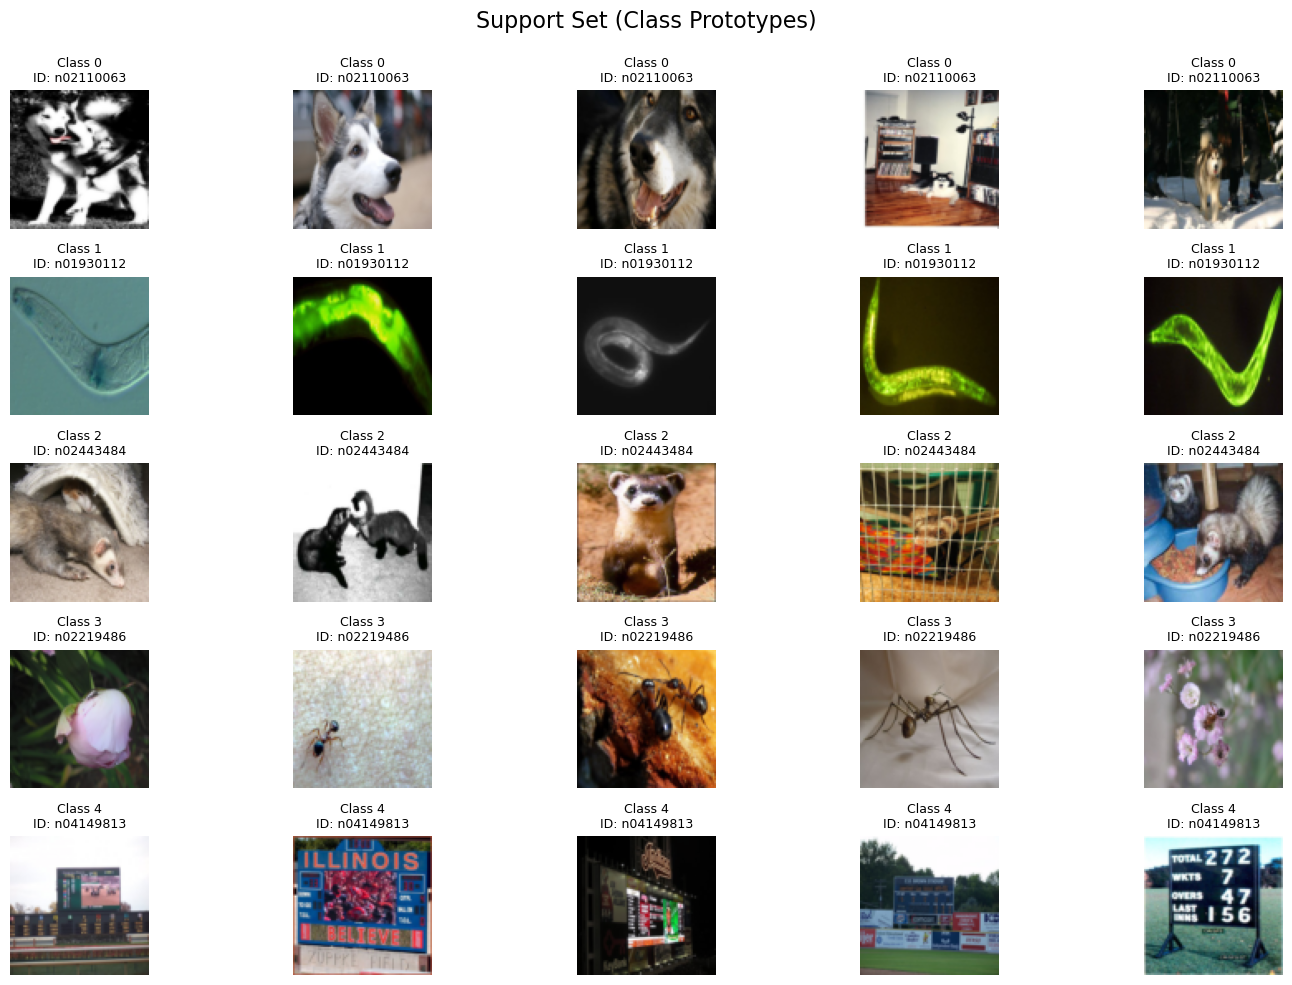

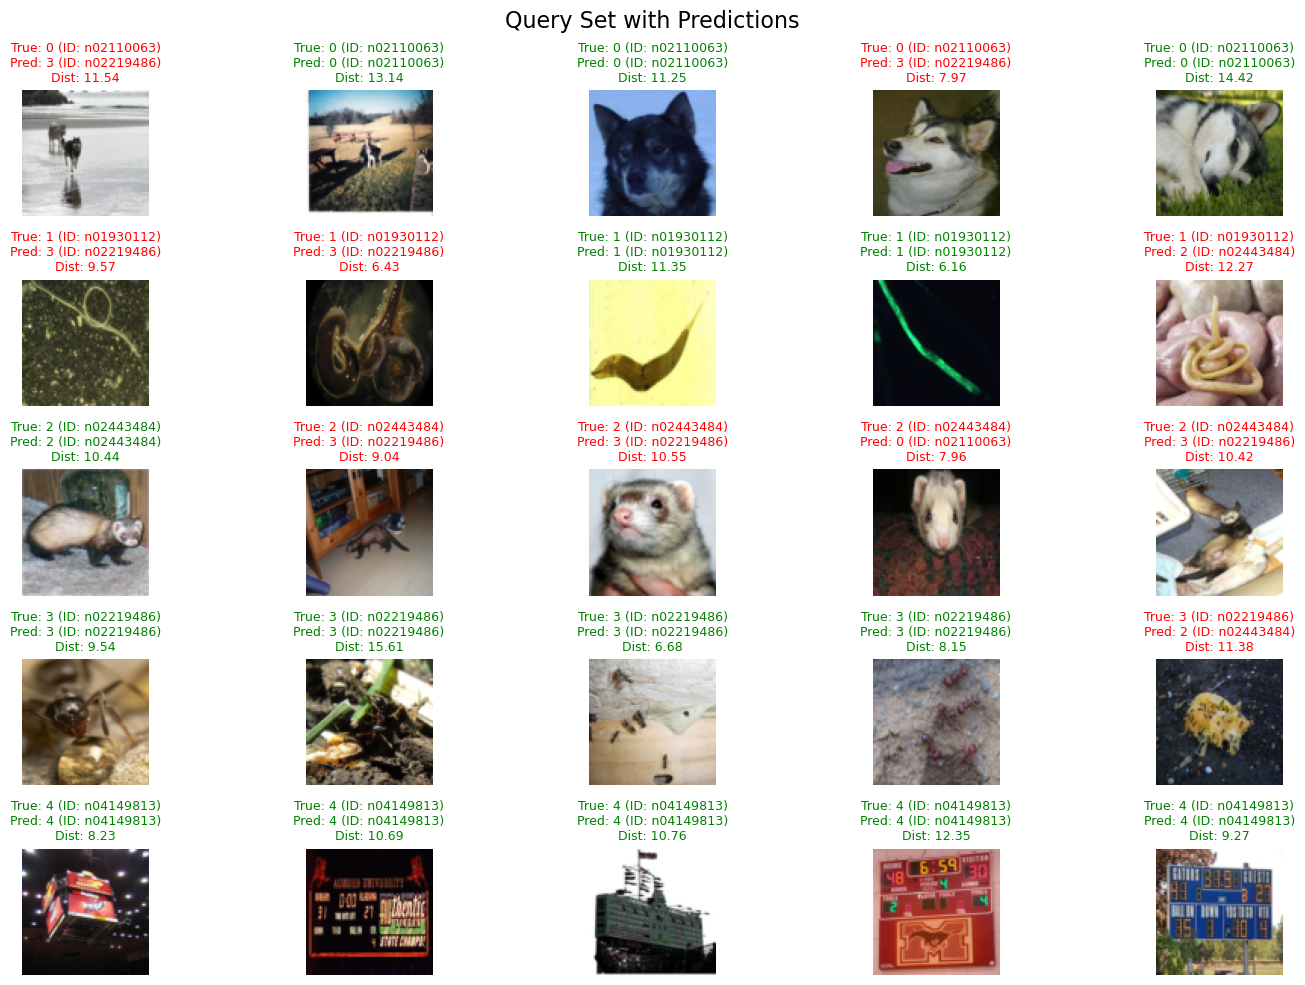

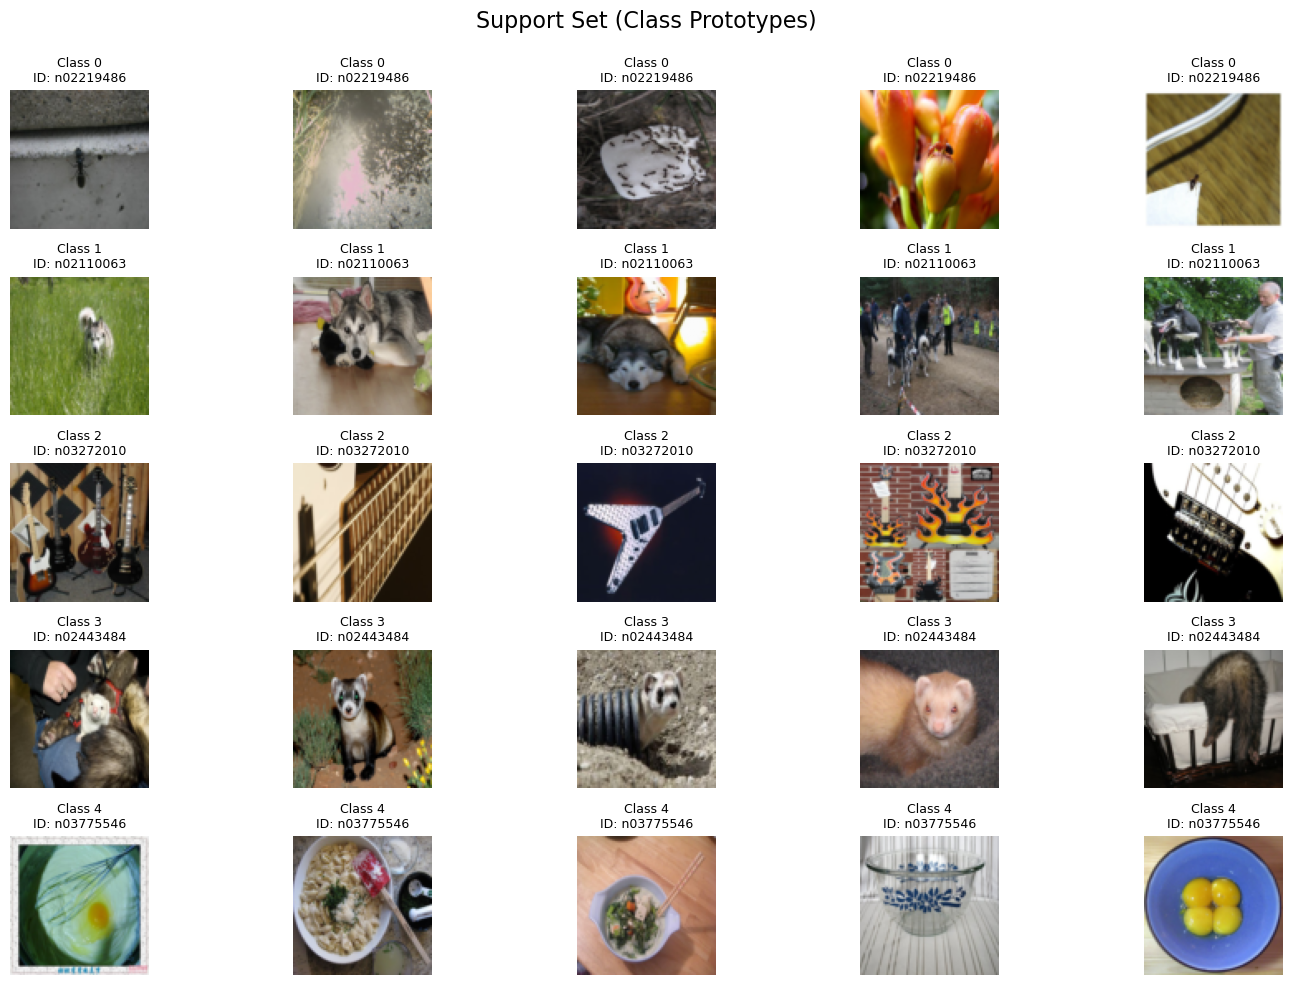

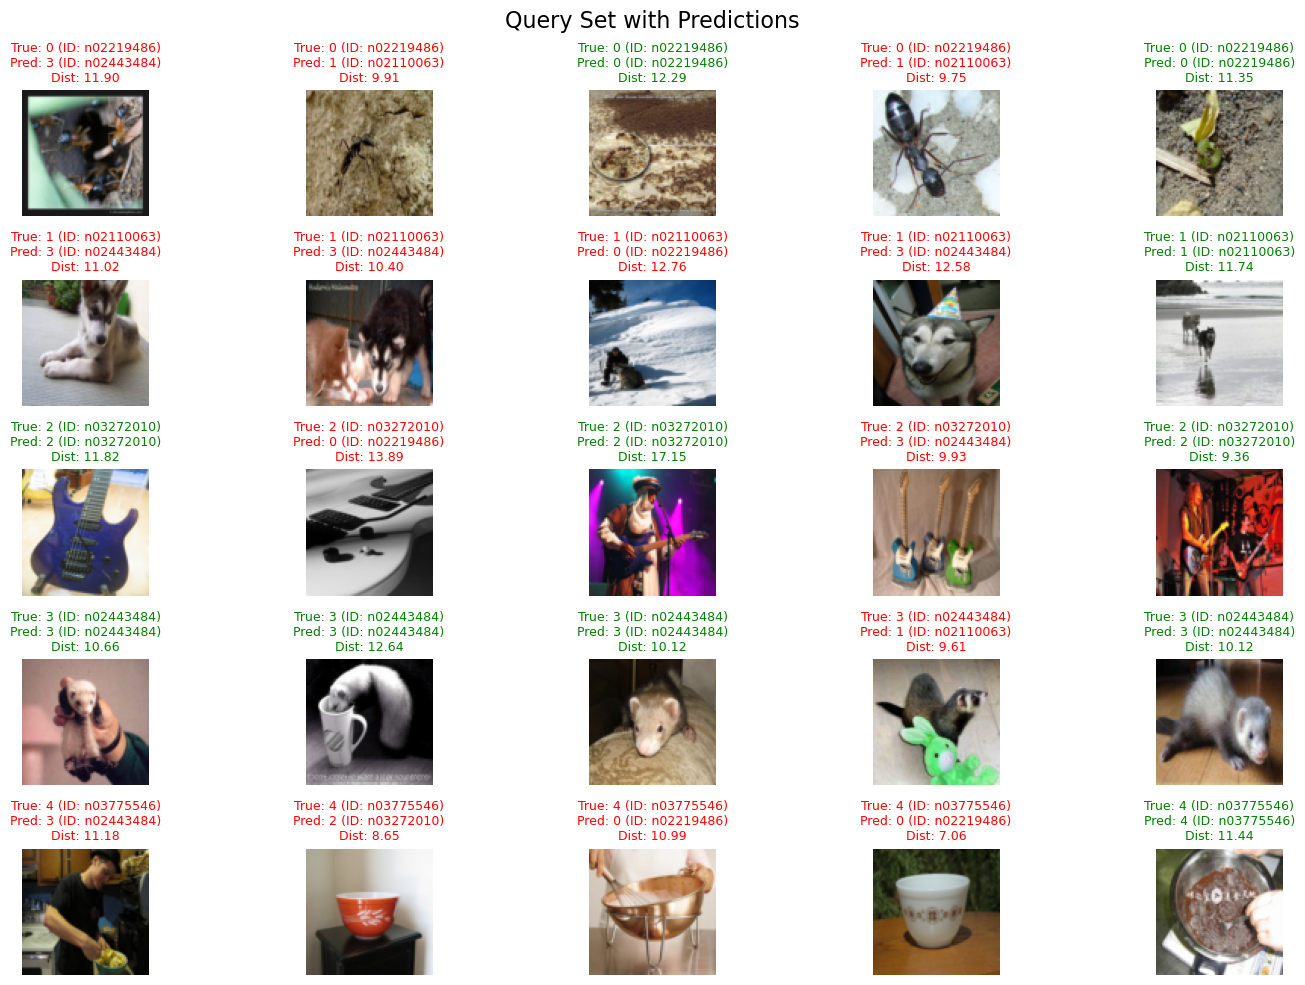

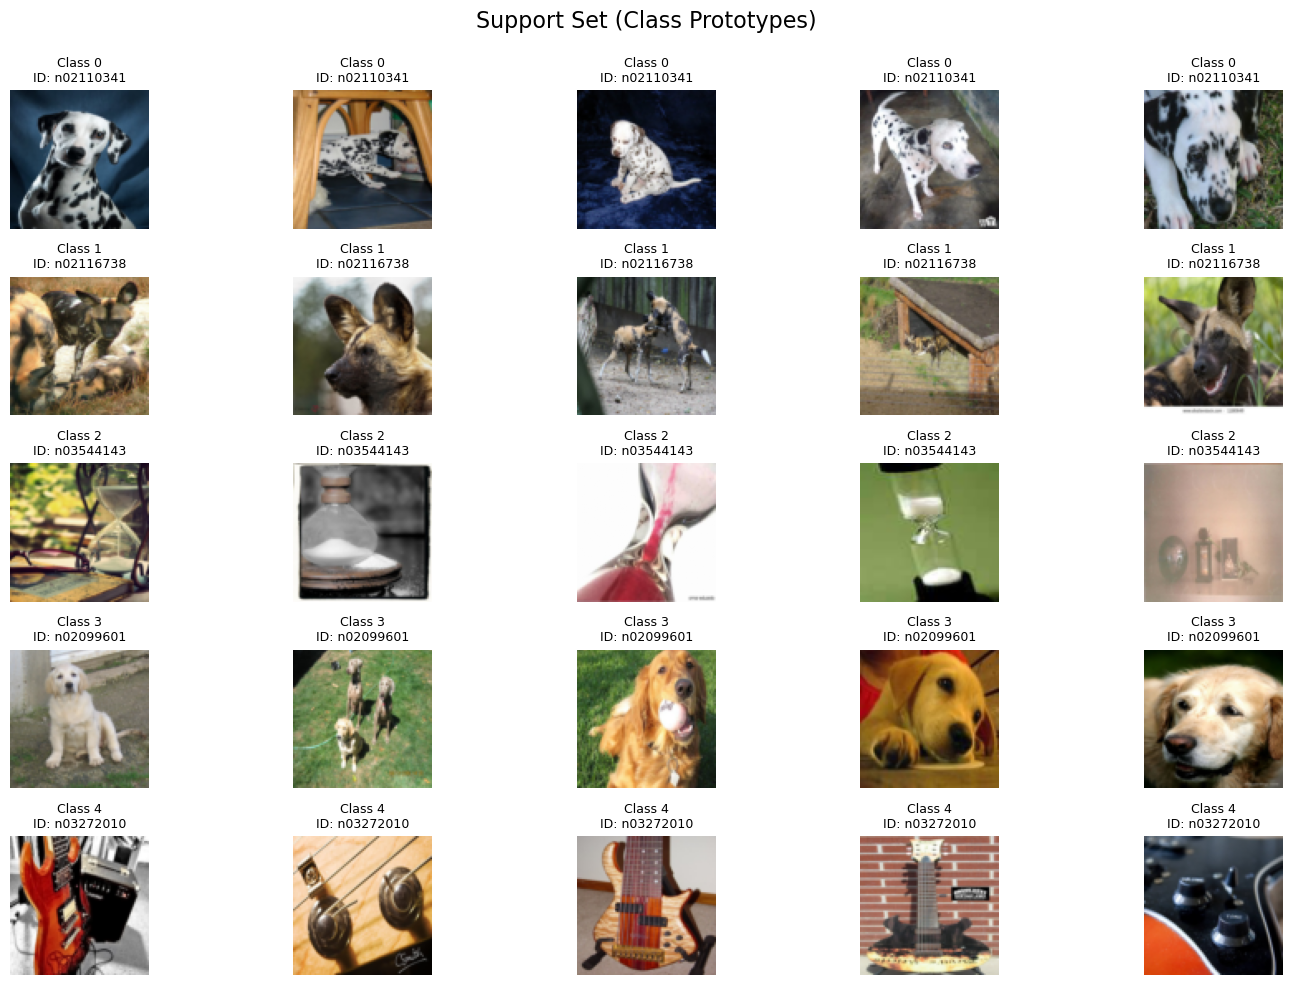

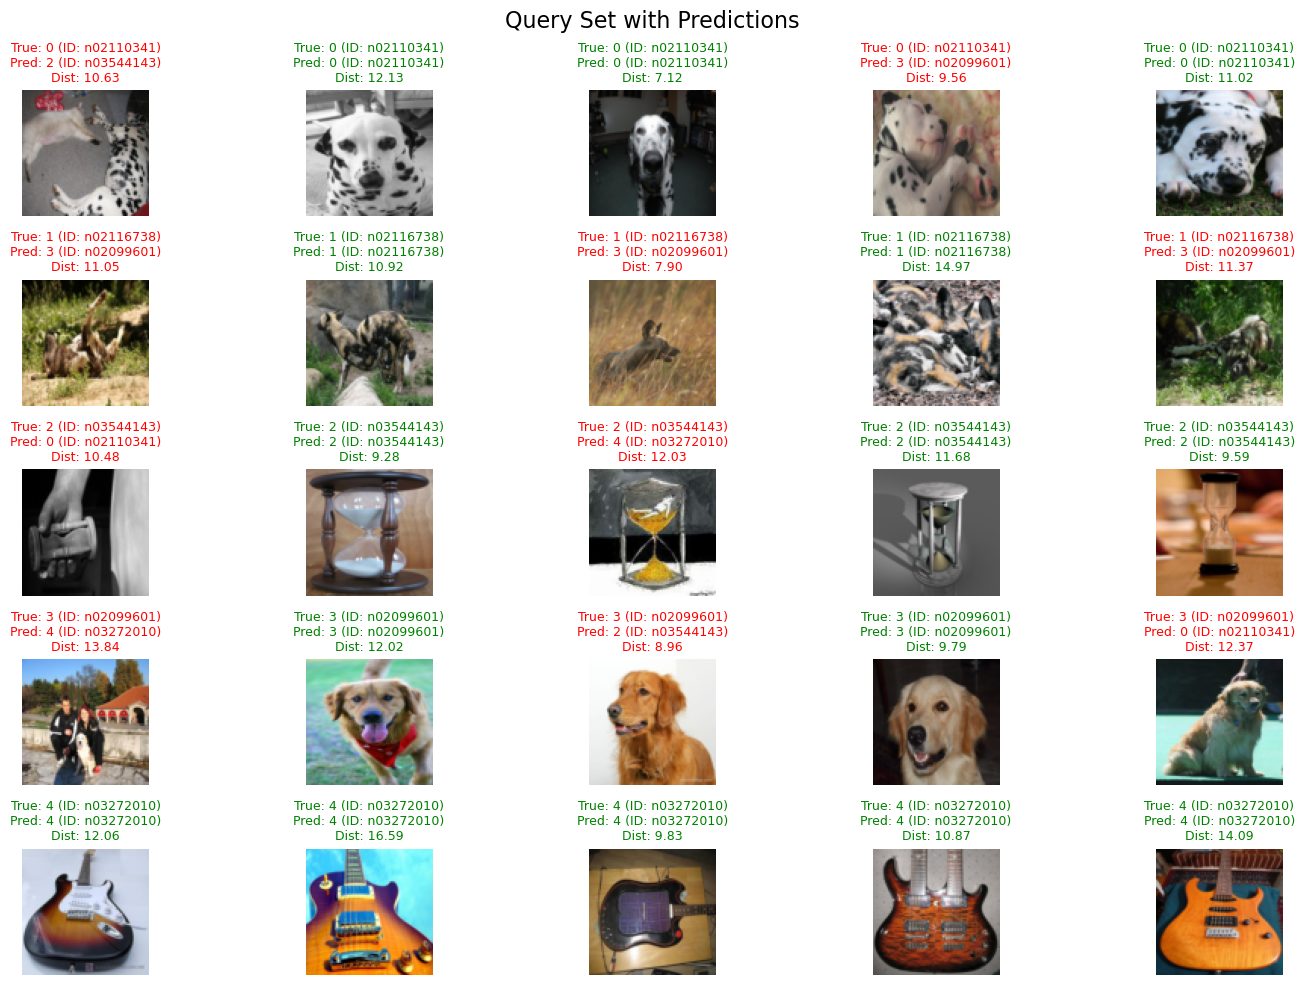

In [75]:
import torch
import torch.nn as nn
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import transforms
import os
import math

# Set random seeds for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define inverse transform to convert tensors back to images
def inverse_transform(tensor):
    """Convert normalized tensor to image for visualization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    # Un-normalize
    tensor = tensor * std + mean
    
    # Clip values to [0, 1]
    tensor = torch.clamp(tensor, 0, 1)
    
    # Convert to numpy array and transpose to (H, W, C)
    return tensor.cpu().numpy().transpose(1, 2, 0)

# Load the saved model
def load_model():
    model = ProtoNet(x_dim=3, hid_dim=64, z_dim=64)
    checkpoint = torch.load('best_protonet_model.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f"Loaded model from epoch {checkpoint['epoch']} with validation accuracy {checkpoint['val_acc']:.4f}")
    return model

# Function to create an episode and visualize it
def visualize_episode(model, test_dataset, n_way=5, n_support=5, n_query=5):
    """Create an episode, visualize support and query sets, and show model predictions"""
    # Create class mapping for test set
    test_class_map = {}
    for idx, (_, label) in enumerate(test_dataset):
        if label not in test_class_map:
            test_class_map[label] = []
        test_class_map[label].append(idx)
    
    # Randomly select n_way classes
    classes = random.sample(list(test_class_map.keys()), n_way)
    
    # Collect original class labels for reference
    original_classes = classes
    
    support_samples = []
    support_labels = []
    query_samples = []
    query_labels = []
    original_images_support = []
    original_images_query = []
    
    for i, cls in enumerate(classes):
        # Get indices of samples for this class
        cls_indices = test_class_map[cls]
        
        # Randomly select n_support + n_query samples
        selected_indices = random.sample(cls_indices, n_support + n_query)
        
        # Split into support and query sets
        support_indices = selected_indices[:n_support]
        query_indices = selected_indices[n_support:]
        
        # Add samples to support and query sets
        for idx in support_indices:
            img, _ = test_dataset[idx]
            support_samples.append(img)
            support_labels.append(i)  # Use index as the label
            
            # Store original image for visualization
            original_images_support.append((img, i, cls))
        
        for idx in query_indices:
            img, _ = test_dataset[idx]
            query_samples.append(img)
            query_labels.append(i)  # Use index as the label
            
            # Store original image for visualization
            original_images_query.append((img, i, cls))
    
    # Convert to tensors
    support_samples = torch.stack(support_samples)
    support_labels = torch.tensor(support_labels)
    query_samples = torch.stack(query_samples)
    query_labels = torch.tensor(query_labels)
    
    # Move to device
    support_samples = support_samples.to(device)
    support_labels = support_labels.to(device)
    query_samples = query_samples.to(device)
    query_labels = query_labels.to(device)
    
    # Compute embeddings
    with torch.no_grad():
        support_embeddings = model(support_samples)
        query_embeddings = model(query_samples)
    
    # Compute prototypes
    prototypes = torch.zeros(n_way, support_embeddings.shape[1]).to(device)
    for i in range(n_way):
        mask = support_labels == i
        prototypes[i] = support_embeddings[mask].mean(0)
    
    # Compute distances and predictions
    dists = torch.cdist(query_embeddings, prototypes)**2
    log_p_y = torch.nn.functional.log_softmax(-dists, dim=1)
    _, predictions = log_p_y.max(1)
    
    # Calculate accuracy
    accuracy = torch.eq(predictions, query_labels).float().mean().item()
    print(f"Episode accuracy: {accuracy:.4f}")
    
    # Calculate distances to prototypes for each query sample
    distances = []
    for i in range(len(query_samples)):
        dist_to_prototypes = dists[i].cpu().numpy()
        distances.append(dist_to_prototypes)
    
    # Convert predictions and query_labels to numpy arrays
    predictions = predictions.cpu().numpy()
    query_labels = query_labels.cpu().numpy()
    
    # Visualize the support set (organized by class)
    plt.figure(figsize=(15, 10))
    plt.suptitle("Support Set (Class Prototypes)", fontsize=16)
    
    # Organize support images by class for better visualization
    for class_idx in range(n_way):
        class_images = [(img, label, cls) for img, label, cls in original_images_support if label == class_idx]
        
        for i, (img_tensor, _, orig_class) in enumerate(class_images):
            # Calculate position for this class's images
            plt.subplot(n_way, n_support, class_idx * n_support + i + 1)
            img = inverse_transform(img_tensor)
            plt.imshow(img)
            plt.title(f"Class {class_idx}\nID: {orig_class}", fontsize=9)
            plt.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig('protonet_support_set.png')
    
    # Visualize query set with predictions
    plt.figure(figsize=(15, 10))
    plt.suptitle("Query Set with Predictions", fontsize=16)
    
    # Calculate grid dimensions
    total_queries = len(original_images_query)
    grid_cols = min(5, total_queries)
    grid_rows = math.ceil(total_queries / grid_cols)
    
    for i, (img_tensor, true_label, orig_class) in enumerate(original_images_query):
        plt.subplot(grid_rows, grid_cols, i + 1)
        img = inverse_transform(img_tensor)
        plt.imshow(img)
        
        pred_label = predictions[i]
        is_correct = pred_label == true_label
        color = 'green' if is_correct else 'red'
        
        # Get closest prototype distance
        closest_dist = float(distances[i][pred_label])
        
        plt.title(f"True: {true_label} (ID: {orig_class})\nPred: {pred_label} (ID: {original_classes[pred_label]})\nDist: {closest_dist:.2f}", 
                  color=color, fontsize=9)
        plt.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig('protonet_predictions.png')
    
    # Print complete analysis
    print("\nDetailed Analysis:")
    print("=================")
    print(f"Classes in this episode: {original_classes}")
    print(f"Number of support samples per class: {n_support}")
    print(f"Number of query samples per class: {n_query}")
    print(f"Overall accuracy: {accuracy:.4f}")
    
    # Print per-class accuracy
    print("\nPer-class accuracy:")
    for cls_idx in range(n_way):
        cls_mask = query_labels == cls_idx
        if sum(cls_mask) > 0:
            cls_correct = sum((predictions == query_labels) & cls_mask)
            cls_acc = cls_correct / sum(cls_mask)
            print(f"Class {cls_idx} (ID: {original_classes[cls_idx]}): {cls_acc:.4f}")
    
    # Print confusion matrix
    confusion = np.zeros((n_way, n_way), dtype=int)
    for i in range(len(query_labels)):
        confusion[query_labels[i]][predictions[i]] += 1
    
    print("\nConfusion Matrix:")
    print("True\Pred", end="")
    for i in range(n_way):
        print(f"  {i}  ", end="")
    print()
    
    for i in range(n_way):
        print(f"    {i}    ", end="")
        for j in range(n_way):
            print(f" {confusion[i][j]:3d} ", end="")
        print()
        
    # Return details for further analysis if needed
    return {
        'accuracy': accuracy,
        'predictions': predictions,
        'true_labels': query_labels,
        'distances': distances,
        'original_classes': original_classes
    }

# Main function to run the visual test
def run_visual_test():
    model = load_model()
    
    results = []
    # Create multiple episodes to visualize
    for episode in range(3):
        print(f"\nVisualizing Episode {episode+1}")
        episode_results = visualize_episode(model, test_dataset)
        results.append(episode_results)
    
    # Calculate overall statistics across episodes
    overall_accuracy = np.mean([r['accuracy'] for r in results])
    print(f"\nOverall accuracy across all episodes: {overall_accuracy:.4f}")
    
    return results

if __name__ == "__main__":
    run_visual_test()